mode=exact  noise=local_dep@0.05  theta=0.30pi  J=0.35  beta=3
exact asymptotic per-round decay rate |lambda_2| = 0.9149

observable           <O>_0   <O>_inf  n_eps   |ratio|
--------------------------------------------------------
X1Z2               +0.0000   +0.2410     16    0.9983  <- not converged by N_MAX
X1X2Z3             +0.0000   +0.0890     16    1.0008  <- not converged by N_MAX
X1X2X3Z4           +0.0000   +0.0319     16    1.0030  <- not converged by N_MAX
X1X2X3X4Z5         +0.0000   +0.0087     16    0.9973  <- not converged by N_MAX

Read it as: n_eps is how many collisions until <O> stops moving, and |ratio|
is the per-collision decay factor that observable actually sees -- <O>_inf is the IDEAL (noiseless) target, and the decay rate above is exact, not an n=N_MAX proxy.


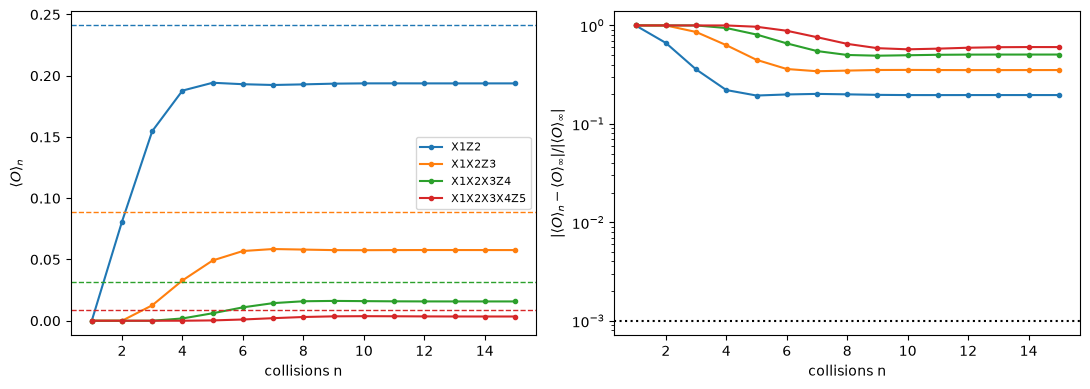

In [2]:
"""
Collision model: how many collisions until <O> converges?

The question this script answers: given a system that repeatedly collides with
fresh environment qubits, how fast does the expectation value of an observable
settle down -- and how does that depend on (a) the support/weight of the
observable and (b) the noise channel?

Layout:
    PART 1  system size, observables
    PART 2  the pieces of the dynamical map (ancilla prep, collision, noise)
    PART 3  assemble a circuit for n collisions
    PART 4  run it  ("exact" = averaged dynamics, or "shots" = sampled)
    PART 5  exact one-round channel and analytic fixed point
    PART 6  sweep n, report convergence against the exact fixed point, plot

PARTS 1-3 are backend-agnostic: they only build circuits and Pauli operators.
Only PART 4 cares whether you want averaged dynamics or shot sampling.

A performance note up front, since PART 5/6 go out of their way to avoid two
slow paths:
  1. Rebuilding and re-simulating an n-collision circuit from scratch for
     every n in the sweep is wasteful -- one collision round is always the
     SAME fixed map, so PART 5 builds it once and just re-applies it n times
     (cheap matrix-vector products) instead of re-simulating growing circuits.
  2. Simulating a literal N_SYS-qubit depolarizing channel ("global_dep")
     through Aer is prohibitively slow -- it has 4**N_SYS Pauli terms, and at
     N_SYS=5 that's 1024, to the point that even ONE round didn't finish in
     60 seconds.  Since that channel has an exact, trivial closed form, PART 5
     applies it directly as a matrix instead of asking Aer to simulate it.
"""

import numpy as np
from qiskit import QuantumCircuit
from qiskit.quantum_info import SparsePauliOp, DensityMatrix
from qiskit_aer import AerSimulator
from qiskit_aer.noise import (
    depolarizing_error,
    amplitude_damping_error,
    pauli_error,
)
import matplotlib.pyplot as plt


# =============================================================================
# PART 1 -- system and observables
# =============================================================================

N_SYS = 5                 # system qubits
ANC = N_SYS               # index of the single ancilla qubit (reused each collision)
N_TOTAL = N_SYS + 1
D_SYS = 2 ** N_SYS         # system Hilbert space dimension


def pauli_on(qubits, letters="Z", n=N_SYS):
    """
    Build a Pauli string with given single-qubit letters on given qubit indices,
    identity elsewhere.  pauli_on([0, 2], "Z") on 3 qubits -> "ZIZ".

    Careful: in Qiskit the LEFTMOST character is the HIGHEST qubit index.
    This helper takes physical qubit indices so you don't have to think about it.
    The Pauli weight is simply len(qubits).
    """
    if isinstance(letters, str) and len(letters) == 1:
        letters = letters * len(qubits)
    chars = ["I"] * n
    for q, L in zip(qubits, letters):
        chars[q] = L
    return "".join(reversed(chars))


def observable(strings, weights):
    """
    strings : list of Pauli strings (Qiskit convention: leftmost character is
              the HIGHEST qubit index), e.g. ["IIIIZ", "IIIZZ"].
              Use pauli_on(qubits, letters) to build these from physical qubit
              indices without having to think about the reversal yourself.
    weights : list or array of coefficients, one per string.

    e.g. observable([pauli_on([0], "Z"), pauli_on([0, 1], "ZZ")], [1.0, 0.5])
         -> 1.0 * Z_0  +  0.5 * Z_0 Z_1
    """
    return SparsePauliOp.from_list(list(zip(strings, np.asarray(weights)))).simplify()


# The observables to compare.  Weight = size of the support.
#
# Why these specific strings and not e.g. plain Z-chains or X-chains: the
# collision only pumps qubit 0 (it's the one that swaps with the ancilla),
# and free_evolution's ZZ coupling propagates that polarization outward
# through an X...XZ pattern -- a string of X's ending in a Z.  Numerically
# probing the steady state confirms this: among ALL weight-k Pauli strings,
# X_0 X_1 ... X_{k-2} Z_{k-1} is (one of) the largest in |<O>_inf|, both with
# and without noise.  A plain Z-chain or a string with Z's in the middle
# instead has essentially zero steady-state weight (<1e-10) here, because it
# doesn't overlap the channel's one slowly-decaying mode -- that's why the
# original observables (mixed Z/Y strings) all looked "trivially converged":
# their target was 0, and 0 vs 0 shows no offset no matter what the noise
# does.  These strings give a real, weight-graded ladder of nonzero targets
# to compare noisy vs. ideal against.
OBSERVABLES = {
    "X1Z2":       observable([pauli_on([0, 1], "XZ")], [1.0]),
    "X1X2Z3":     observable([pauli_on([0, 1, 2], "XXZ")], [1.0]),
    "X1X2X3Z4":   observable([pauli_on([0, 1, 2, 3], "XXXZ")], [1.0]),
    "X1X2X3X4Z5": observable([pauli_on([0, 1, 2, 3, 4], "XXXXZ")], [1.0]),
}


# =============================================================================
# PART 2 -- the pieces of the dynamical map
#
# One "collision" = fresh environment qubit  ->  system-environment unitary
#                   ->  (optionally) noise on the system.
# Each piece is a small circuit fragment, so the same code works whether you
# later simulate it exactly or shot-by-shot.
# =============================================================================

# --- 2a. initial system state ------------------------------------------------

def initial_state(qc):
    """|+> on every system qubit.  Change freely; this is rho_0."""
    for q in range(N_SYS):
        qc.h(q)


# --- 2b. fresh environment qubit --------------------------------------------

BETA = 3                 # inverse temperature of the ancilla bath
OMEGA = 1.0                # ancilla energy gap (sets the Boltzmann weight with BETA)


def thermal_excited_population(beta, omega=OMEGA):
    """
    Boltzmann population of the excited state for a two-level ancilla with
    energy gap omega, i.e. the diagonal of the Gibbs state
    rho_E = exp(-beta H) / Z with H = omega |1><1|:

        p_e(beta) = 1 / (1 + exp(beta * omega))

    beta -> 0   (T -> inf) : p_e -> 0.5  (maximally mixed bath)
    beta -> inf (T -> 0)   : p_e -> 0    (ground-state bath)
    """
    if np.isinf(beta):
        return 0.0
    return 1.0 / (1.0 + np.exp(beta * omega))


def prepare_ancilla(qc, beta=BETA):
    """
    Reset the ancilla to |0>, then flip it with the Boltzmann probability
    p_e(beta) so it arrives in the Gibbs state diag(1 - p_e, p_e) at inverse
    temperature beta -- the standard collision-model choice of bath state --
    without needing a purifying qubit.  Under shot-based simulation each shot
    genuinely draws its own environment state, which is the physically honest
    picture.
    """
    qc.reset(ANC)
    p_e = thermal_excited_population(beta)
    if p_e > 0:
        flip = pauli_error([("X", p_e), ("I", 1 - p_e)])
        qc.append(flip.to_instruction(), [ANC])


# --- 2c. system-environment interaction -------------------------------------

THETA = 0.3 * np.pi       # 0 = no collision, pi/2 = full excitation exchange

RANDOM_COLLISION_QUBIT = False    # False: ancilla always collides with qubit 0
                                   # True:  each round's collision PARTNER is
                                   #        drawn uniformly at random from the
                                   #        N_SYS system qubits (independently
                                   #        every round)

def collision_unitary(qc, qubit=0):
    """
    Partial excitation exchange between the ancilla and system qubit `qubit`
    (qubit 0 unless the caller asks for a different one -- see
    RANDOM_COLLISION_QUBIT):
        exp(-i THETA/2 (XX + YY)) = RXX(THETA) . RYY(THETA)
    (XX and YY commute, so the product is exact -- no Trotter error.)
    Written with rxx/ryy rather than XXPlusYYGate because Aer's EstimatorV2
    does not transpile, and executes these two natively.
    """
    qc.rxx(THETA, qubit, ANC)
    qc.ryy(THETA, qubit, ANC)


def random_collision_qubit():
    """
    Which system qubit the ancilla collides with THIS round.  Fixed at qubit
    0 unless RANDOM_COLLISION_QUBIT is set, in which case it's drawn fresh
    (uniformly, independently) every round -- used by collision_circuit()
    for MODE="shots" (a real per-shot random draw) and, in aggregate, by
    system_channel_matrix() for MODE="exact" (see that function's docstring
    for why the "exact" path doesn't need to sample this at all).
    """
    return int(np.random.randint(N_SYS)) if RANDOM_COLLISION_QUBIT else 0


# --- 2d. free system evolution between collisions ---------------------------

J_COUPLING = 0.35         
H_FIELD = 0.25            

def free_evolution(qc):
    for q in range(N_SYS - 1):
        qc.rzz(2 * J_COUPLING, q, q + 1)
    for q in range(N_SYS):
        qc.rx(2 * H_FIELD, q)


# --- 2e. noise on the system ------------------------------------------------

NOISE_KIND = "local_dep"  # "none" | "global_dep" | "local_dep" | "local_damp"
NOISE_STRENGTH = 0.05     # matched so all kinds give weight-1 Z fidelity 1-s

def apply_noise(qc):
    """
    Appended as an explicit channel inside the circuit (not via a NoiseModel)
    so that you can see exactly where it acts, and so the exact and shot-based
    backends see the identical model.

      global_dep : one n-qubit depolarizing channel.  Scales EVERY non-identity
                   Pauli by the same factor -> observable weight does NOT
                   matter.  This is the null model for your support study.
                   NOTE: PART 5's exact-mode path does NOT run this branch --
                   simulating it through Aer at N_SYS=5 is far too slow (see
                   the module docstring), so it applies the same channel as a
                   closed-form matrix instead (global_depolarizing_matrix).
                   This branch still runs for MODE="shots", and is kept here
                   so the circuit-level model is fully written out in one
                   place.
      local_dep  : independent single-qubit depolarizing.  A weight-k Pauli
                   decays like (1-s)^k -> weight DOES matter.
      local_damp : amplitude damping.  Not Pauli-diagonal, so it also MOVES the
                   fixed point rather than only damping towards maximally mixed.
    """
    if NOISE_KIND == "none" or NOISE_STRENGTH == 0:
        return
    if NOISE_KIND == "global_dep":
        err = depolarizing_error(NOISE_STRENGTH, N_SYS)
        qc.append(err.to_instruction(), list(range(N_SYS)))
    elif NOISE_KIND == "local_dep":
        err = depolarizing_error(NOISE_STRENGTH, 1)
        for q in range(N_SYS):
            qc.append(err.to_instruction(), [q])
    elif NOISE_KIND == "local_damp":
        err = amplitude_damping_error(NOISE_STRENGTH)
        for q in range(N_SYS):
            qc.append(err.to_instruction(), [q])
    else:
        raise ValueError(NOISE_KIND)


# =============================================================================
# PART 3 -- assemble the circuit for n collisions
# =============================================================================

def collision_circuit(n_collisions):
    """
    Width stays constant (the ancilla is reset and reused); depth grows
    linearly in n_collisions.  No measurements: the estimator adds those.

    Each round's collision partner is drawn independently by
    random_collision_qubit() -- a real per-shot draw when RANDOM_COLLISION_QUBIT
    is set, matching how MODE="shots" already draws a fresh ancilla state
    every round.
    """
    qc = QuantumCircuit(N_TOTAL)
    initial_state(qc)
    for _ in range(n_collisions):
        prepare_ancilla(qc)
        collision_unitary(qc, random_collision_qubit())
        free_evolution(qc)
        apply_noise(qc)
    return qc


def pad_for_ancilla(obs):
    """Observable acts on N_SYS qubits; the circuit has one more.  Pad with I."""
    return SparsePauliOp("I").tensor(obs)


# =============================================================================
# PART 4 -- run it
#
# MODE = "exact"  -> density-matrix simulation, i.e. the AVERAGED dynamics.
#                    Noise channels are applied analytically, no sampling.
# MODE = "shots"  -> statevector simulation; each shot samples its own error
#                    realisation and its own measurement outcome.
# Everything above is shared; only this part changes.
# =============================================================================

MODE = "exact"
SHOTS = 4096              # only used when MODE == "shots"


def make_estimator(mode=MODE):
    if mode == "exact":
        from qiskit_aer.primitives import EstimatorV2 as AerEstimator
        # precision=0 -> Aer returns the exact expectation value with no
        # artificial Gaussian "shot noise" added on top.
        return AerEstimator(options={
            "backend_options": {"method": "density_matrix"},
            "default_precision": 0.0,
        })
    elif mode == "shots":
        # to be implemented
        raise NotImplementedError("shots mode not implemented yet")
    raise ValueError(mode)


def expectation_values(n_collisions, obs_dict, estimator):
    """One circuit, all observables evaluated on it."""
    circ = collision_circuit(n_collisions)
    names = list(obs_dict)
    obs = [pad_for_ancilla(obs_dict[k]) for k in names]
    result = estimator.run([(circ, obs)]).result()
    vals = np.atleast_1d(result[0].data.evs)
    return dict(zip(names, vals))


# =============================================================================
# PART 5 -- exact one-round channel and analytic fixed point
#
# The ancilla is reset and traced out every round, so one round is a FIXED,
# n-independent CPTP linear map Phi on the system's 32x32 density matrix.
# Phi lives on a (2^N_SYS)^2 = 1024-dim space, small enough to build exactly
# and diagonalize with dense numpy.  Once Phi is built (ONCE), we get:
#   - the exact <O>_inf, from Phi's eigenvector at eigenvalue 1;
#   - the exact asymptotic per-round decay rate, from Phi's next eigenvalue;
#   - the entire "exact"-mode trajectory <O>_n for n=0..N_MAX, just by
#     applying Phi to the state N_MAX times (cheap matrix-vector products) --
#     instead of rebuilding and re-simulating a circuit of growing depth for
#     every n, which is what made PART 6's sweep so slow before.
# =============================================================================

def round_circuit(include_noise=True, collision_qubit=0):
    """
    One collision round in isolation (no accumulation over n).
    include_noise=False builds the round WITHOUT the noise step -- used for
    NOISE_KIND="global_dep", where the noise is applied separately as a
    closed-form matrix instead (see global_depolarizing_matrix below).
    collision_qubit fixes which system qubit collides with the ancilla THIS
    round -- system_channel_matrix() sweeps this over all N_SYS qubits when
    RANDOM_COLLISION_QUBIT is set (see its docstring for why).
    """
    qc = QuantumCircuit(N_TOTAL)
    prepare_ancilla(qc)
    collision_unitary(qc, collision_qubit)
    free_evolution(qc)
    if include_noise:
        apply_noise(qc)
    return qc


def round_superop(include_noise=True, collision_qubit=0):
    """
    Exact superoperator of one round (system+ancilla), as the
    (2^N_TOTAL)^2 x (2^N_TOTAL)^2 matrix Aer builds via its 'superop' method.
    This reuses the circuit's own reset/noise instructions rather than
    re-deriving their Kraus operators by hand, so it stays exactly in sync
    with whatever PART 2 defines (except global_dep -- see system_channel_matrix).
    """
    qc = round_circuit(include_noise=include_noise, collision_qubit=collision_qubit)
    qc.save_superop()
    backend = AerSimulator(method="superop")
    result = backend.run(qc).result()
    return np.asarray(result.data(0)["superop"])


def global_depolarizing_matrix(p):
    """
    The exact effect of the N_SYS-qubit depolarizing channel used by
    NOISE_KIND="global_dep", built directly instead of simulated:

        Lambda(rho) = (1 - p) * rho  +  p * Tr(rho) * I / D_SYS

    Pauli terms in Aer lag too much. This is quicker.
    """
    dim = D_SYS * D_SYS
    M = (1 - p) * np.eye(dim, dtype=complex)
    vec_identity = np.zeros(dim, dtype=complex)
    for k in range(D_SYS):
        vec_identity[k * D_SYS + k] = 1.0        # vec(I_D_SYS)
    for a in range(D_SYS):
        diag_col = a * D_SYS + a                 # column for input |a><a|
        M[:, diag_col] += (p / D_SYS) * vec_identity
    return M


def system_channel_matrix(include_noise=True, collision_qubit=None):
    """
    Builds the channel matrix with the noise model baked in already.
    """
    if collision_qubit is None and RANDOM_COLLISION_QUBIT:
        per_qubit = [system_channel_matrix(include_noise, collision_qubit=q)
                     for q in range(N_SYS)]
        return np.mean(per_qubit, axis=0)
    q = 0 if collision_qubit is None else collision_qubit

    bypass_noise = include_noise and NOISE_KIND == "global_dep" and NOISE_STRENGTH > 0
    S = round_superop(include_noise=include_noise and not bypass_noise, collision_qubit=q)
    full = 2 * D_SYS

    # Columns of E are vec(|0><0|_ANC (x) |a><b|_sys) for every system basis
    # matrix |a><b|; evolving all 1024 of them through S in one matmul is far
    # cheaper than looping qiskit objects one basis element at a time.
    E = np.zeros((full * full, D_SYS * D_SYS), dtype=complex)
    for b in range(D_SYS):
        for a in range(D_SYS):
            E[b * full + a, b * D_SYS + a] = 1.0
    out = S @ E                                            # (4096, 1024)

    Phi = np.zeros((D_SYS * D_SYS, D_SYS * D_SYS), dtype=complex)
    for j in range(D_SYS * D_SYS):
        rho_full = out[:, j].reshape(full, full, order="F")
        rho_full = rho_full.reshape(2, D_SYS, 2, D_SYS)
        rho_S = np.einsum("aiaj->ij", rho_full)            # trace out ancilla
        Phi[:, j] = rho_S.reshape(-1, order="F")

    if bypass_noise:
        Phi = global_depolarizing_matrix(NOISE_STRENGTH) @ Phi
    return Phi


def analytic_fixed_points(obs_dict, phi=None):
    """
    Finds the analytical fixed points by 
    diagonalizing the matrix and finding the eigenvalue 1 eigenvector.
    Should work for smaller qubit spaces.

    Returns (fixed_points: dict[name -> float], decay_rate: float).
    """
    if phi is None:
        phi = system_channel_matrix()
    eigvals, eigvecs = np.linalg.eig(phi)

    k_inf = np.argmin(np.abs(eigvals - 1))
    rho_inf = eigvecs[:, k_inf].reshape(D_SYS, D_SYS, order="F")
    rho_inf = rho_inf / np.trace(rho_inf)

    order = np.argsort(-np.abs(eigvals))
    decay_rate = np.abs(eigvals[order[1]])

    fixed = {k: np.trace(obs.to_matrix() @ rho_inf).real
             for k, obs in obs_dict.items()}
    return fixed, decay_rate


def initial_density_matrix():
    """rho_0 simulated from initial_state(), vectorized in the same convention as Phi."""
    qc = QuantumCircuit(N_SYS)
    initial_state(qc)
    return DensityMatrix(qc).data.reshape(-1, order="F")


def analytic_trajectories(obs_dict, n_max, phi=None):
    """
    The exact-mode trajectories <O>_n for n = 0..n_max, computed by repeatedly
    applying the one-round channel Phi to the system state -- Phi is built
    ONCE (the only step that can be slow), and every extra collision after
    that is just a cheap (1024, 1024) matrix-vector product.  Physically
    identical to rebuilding and re-simulating an n-collision circuit for
    every n (validated to agree with that approach to ~1e-15), just without
    paying for the growing circuit N_MAX+1 times over.
    """
    if phi is None:
        phi = system_channel_matrix()
    obs_matrices = {k: obs.to_matrix() for k, obs in obs_dict.items()}

    traj = {k: np.empty(n_max + 1) for k in obs_dict}
    vec = initial_density_matrix()
    for n in range(n_max + 1):
        rho_n = vec.reshape(D_SYS, D_SYS, order="F")
        for k, Omat in obs_matrices.items():
            traj[k][n] = np.trace(Omat @ rho_n).real
        vec = phi @ vec
    return traj


# =============================================================================
# PART 6 -- sweep the number of collisions and look at convergence
# =============================================================================

N_MAX = 15
EPS = 1e-3                # "converged" = within EPS of the ideal fixed point


def main():
    ns = list(range(N_MAX + 1))

    phi_ideal = system_channel_matrix(include_noise=False) 
    fixed_exact, _ = analytic_fixed_points(OBSERVABLES, phi=phi_ideal)

    if MODE == "exact":
        # Exact dynamics are what Phi describes, so get the WHOLE sweep from
        # it directly -- see PART 5's docstring for why this replaces the old
        # "rebuild+resimulate a circuit for every n" approach.
        phi = system_channel_matrix()
        traj = analytic_trajectories(OBSERVABLES, N_MAX, phi=phi)
        _, decay_rate = analytic_fixed_points(OBSERVABLES, phi=phi)
    else:
        # MODE == "shots": genuine per-shot sampling, which Phi cannot stand
        # in for -- this keeps rebuilding a real circuit for every n.  The
        # decay rate is still exact: it's a property of the (possibly noisy)
        # channel itself, not of how the trajectory was simulated.
        estimator = make_estimator()
        traj = {k: [] for k in OBSERVABLES}
        for n in ns:
            for k, v in expectation_values(n, OBSERVABLES, estimator).items():
                traj[k].append(v)
        traj = {k: np.array(v) for k, v in traj.items()}
        _, decay_rate = analytic_fixed_points(OBSERVABLES)

    print(f"mode={MODE}  noise={NOISE_KIND}@{NOISE_STRENGTH}  "
          f"theta={THETA/np.pi:.2f}pi  J={J_COUPLING}  beta={BETA}")
    print(f"exact asymptotic per-round decay rate |lambda_2| = {decay_rate:.4f}\n")
    print(f"{'observable':<16} {'<O>_0':>9} {'<O>_inf':>9} "
          f"{'n_eps':>6}  {'|ratio|':>8}")
    print("-" * 56)
    for k, y in traj.items():
        fixed = fixed_exact[k]             # ideal (noiseless) stationary-state value
        d = np.abs(y - fixed)

        far = np.flatnonzero(d > EPS)
        n_eps = (far[-1] + 1) if far.size else 0

        # Per-collision decay factor: log-linear fit to the tail of d(n),
        # measured against the IDEAL fixed point.  With noise present, d(n)
        # settles onto a nonzero plateau (the noise-induced offset) rather
        # than decaying to zero, so this tail fit -- and n_eps/"not
        # converged" below -- describe distance to the ideal target, not
        # convergence of the noisy dynamics to ITS OWN fixed point (that
        # rate is decay_rate above).
        idx = np.flatnonzero(d > 1e-6)[-8:]
        ratio = (np.exp(np.polyfit(idx, np.log(d[idx]), 1)[0])
                 if len(idx) >= 4 else np.nan)

        flag = "  <- not converged by N_MAX" if n_eps >= N_MAX else ""
        print(f"{k:<16} {y[0]:+9.4f} {fixed:+9.4f} "
              f"{n_eps:6d}  {ratio:8.4f}{flag}")

    print("\nRead it as: n_eps is how many collisions until <O> stops moving, "
          "and |ratio|\nis the per-collision decay factor that observable "
          "actually sees -- <O>_inf is the IDEAL (noiseless) target, and the "
          "decay rate above is exact, not an n=N_MAX proxy.")
    return ns, traj, fixed_exact


def plot(ns, traj, fixed_exact):
    """Distance to the ideal (noiseless) fixed point on a log axis -- a nonzero
    plateau is the noise-induced offset; straight decay is one relaxation mode."""
    import matplotlib.pyplot as plt

    fig, ax = plt.subplots(1, 2, figsize=(11, 4))
    ns_plot = ns[1:]                # drop n=0: "0 collisions" is a degenerate outlier
    for k, y in traj.items():
        y_plot = y[1:]
        line, = ax[0].plot(ns_plot, y_plot, marker=".", label=k)
        ax[0].axhline(fixed_exact[k], ls="--", lw=1, c=line.get_color())
        ax[1].semilogy(ns_plot, np.abs(y_plot - fixed_exact[k])/fixed_exact[k] + 1e-16, marker=".", label=k)
    ax[0].set(xlabel="collisions n", ylabel=r"$\langle O\rangle_n$")
    ax[1].set(xlabel="collisions n", ylabel=r"$|\langle O\rangle_n-\langle O\rangle_\infty|/|\langle O\rangle_\infty|$")
    ax[1].axhline(EPS, ls=":", c="k")
    ax[0].legend(fontsize=8)
    fig.tight_layout()
    plt.show()


if __name__ == "__main__":
    ns, traj, fixed_exact = main()
    plot(ns, traj, fixed_exact)


mode=exact  noise=global_dep@0.02  theta=0.30pi  J=0.35  beta=4
exact asymptotic per-round decay rate |lambda_2| = 0.9743

observable           <O>_0   <O>_inf  n_eps   |ratio|
--------------------------------------------------------
X1Z2               +0.0000   +0.2410     21    1.0009  <- not converged by N_MAX
X1X2Z3             +0.0000   +0.0890     21    1.0038  <- not converged by N_MAX
X1X2X3Z4           +0.0000   +0.0319     21    1.0055  <- not converged by N_MAX
X1X2X3X4Z5         +0.0000   +0.0087     21    0.9939  <- not converged by N_MAX

Read it as: n_eps is how many collisions until <O> stops moving, and |ratio|
is the per-collision decay factor that observable actually sees -- <O>_inf is the IDEAL (noiseless) target, and the decay rate above is exact, not an n=N_MAX proxy.


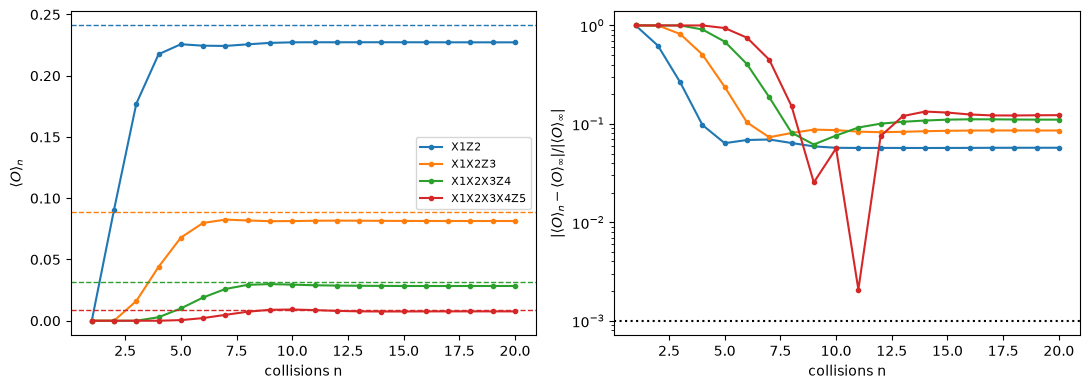

In [3]:
N_SYS = 5                 # system qubits
ANC = N_SYS               # index of the single ancilla qubit (reused each collision)
N_TOTAL = N_SYS + 1
D_SYS = 2 ** N_SYS   

BETA = 4                 # inverse temperature of the ancilla bath
OMEGA = 1.0 
RANDOM_COLLISION_QUBIT = False               # ancilla energy gap (sets the Boltzmann weight with BETA)

J_COUPLING = 0.35         # nearest-neighbour ZZ strength; 0 = no spreading
H_FIELD = 0.25            # transverse field

NOISE_KIND = "global_dep"  # "none" | "global_dep" | "local_dep" | "local_damp"
NOISE_STRENGTH = 0.02     # matched so all kinds give weight-1 Z fidelity 1-s

N_MAX = 20
EPS = 1e-3                # "converged" = within EPS of the ideal fixed point



if __name__ == "__main__":
    ns, traj, fixed_exact = main()
    plot(ns, traj, fixed_exact)

mode=exact  noise=local_dep@0.02  theta=0.30pi  J=0.35  beta=4
exact asymptotic per-round decay rate |lambda_2| = 0.9605

observable           <O>_0   <O>_inf  n_eps   |ratio|
--------------------------------------------------------
X1Z2               +0.0000   +0.2410     21    1.0002  <- not converged by N_MAX
X1X2Z3             +0.0000   +0.0890     21    1.0010  <- not converged by N_MAX
X1X2X3Z4           +0.0000   +0.0319     21    1.0011  <- not converged by N_MAX
X1X2X3X4Z5         +0.0000   +0.0087     21    0.9989  <- not converged by N_MAX

Read it as: n_eps is how many collisions until <O> stops moving, and |ratio|
is the per-collision decay factor that observable actually sees -- <O>_inf is the IDEAL (noiseless) target, and the decay rate above is exact, not an n=N_MAX proxy.


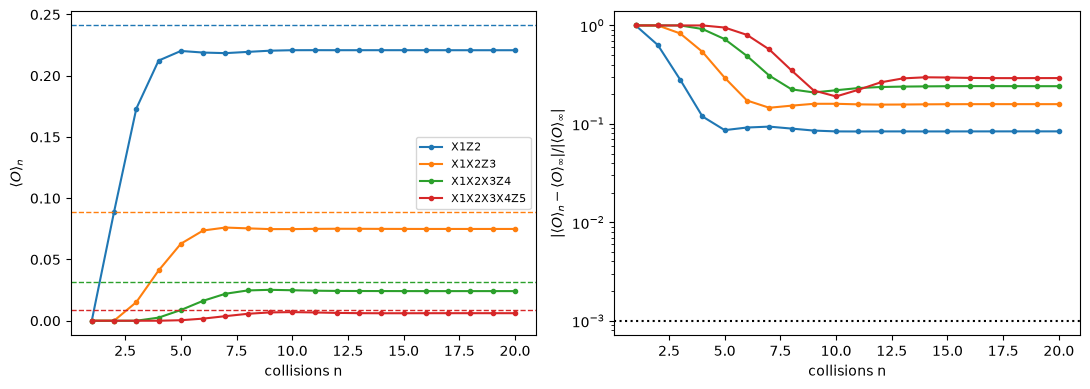

In [4]:
N_SYS = 5                 # system qubits
ANC = N_SYS               # index of the single ancilla qubit (reused each collision)
N_TOTAL = N_SYS + 1
D_SYS = 2 ** N_SYS   

BETA = 4                 # inverse temperature of the ancilla bath
OMEGA = 1.0 
RANDOM_COLLISION_QUBIT = False               # ancilla energy gap (sets the Boltzmann weight with BETA)

J_COUPLING = 0.35         # nearest-neighbour ZZ strength; 0 = no spreading
H_FIELD = 0.25            # transverse field

NOISE_KIND = "local_dep"  # "none" | "global_dep" | "local_dep" | "local_damp"
NOISE_STRENGTH = 0.02     # matched so all kinds give weight-1 Z fidelity 1-s

N_MAX = 20
EPS = 1e-3                # "converged" = within EPS of the ideal fixed point



if __name__ == "__main__":
    ns, traj, fixed_exact = main()
    plot(ns, traj, fixed_exact)

noise-strength sweep: parameters and ideal fixed point

In [5]:
# Noise-strength sweep: relative offset of the noisy fixed point from the ideal one,
#   offset = (<O>_inf(noisy) - <O>_inf(ideal)) / <O>_inf(ideal)
# All model settings (BETA, THETA, J_COUPLING, RANDOM_COLLISION_QUBIT, ...) are
# whatever the cells above left them at.
noise_vals = np.logspace(-4, -1, 10)

phi_ideal = system_channel_matrix(include_noise=False)
fixed_ideal, _ = analytic_fixed_points(OBSERVABLES, phi=phi_ideal)


def plot_offset(offset, title):
    fig, ax = plt.subplots(figsize=(6, 4.5))
    for k, y in offset.items():
        ax.plot(noise_vals, y, marker=".", label=k)
    ax.axhline(0, ls=":", c="k", lw=1)
    ax.set_xscale("log")
    ax.set(xlabel="noise strength", ylabel=r"relative offset of $\langle O\rangle_\infty$",
           title=f"{title}  (random collision qubit = {RANDOM_COLLISION_QUBIT})")
    ax.legend(fontsize=8)
    fig.tight_layout()
    plt.show()

characterizing the offset induced by local dep noise

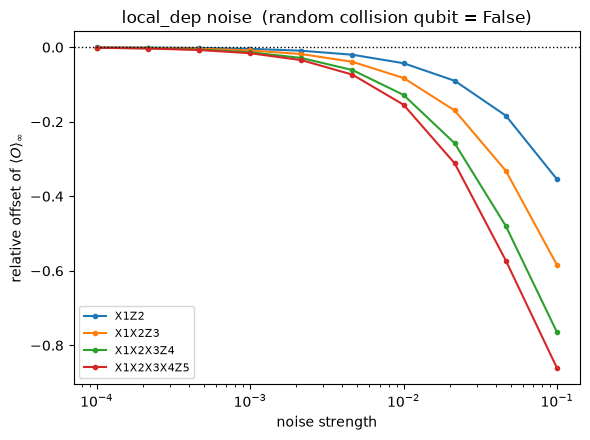

In [6]:
NOISE_KIND = "local_dep"
offset_local_dep = {k: np.empty(len(noise_vals)) for k in OBSERVABLES}
for i, NOISE_STRENGTH in enumerate(noise_vals):
    fixed_noisy, _ = analytic_fixed_points(OBSERVABLES, phi=system_channel_matrix())
    for k in OBSERVABLES:
        offset_local_dep[k][i] = (fixed_noisy[k] - fixed_ideal[k]) / fixed_ideal[k]

plot_offset(offset_local_dep, "local_dep noise")

characterizing the offset induced by global depolarizing noise

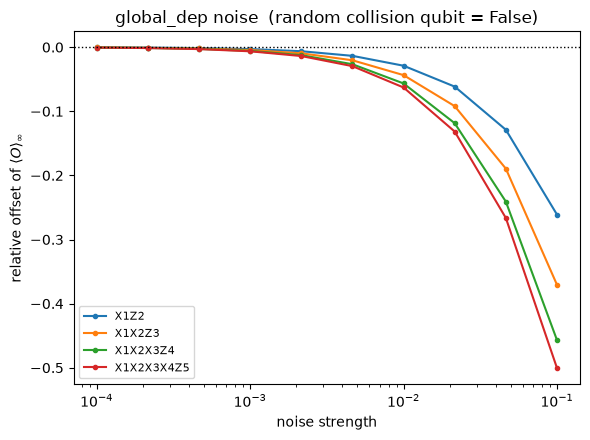

In [7]:
NOISE_KIND = "global_dep"
offset_global_dep = {k: np.empty(len(noise_vals)) for k in OBSERVABLES}
for i, NOISE_STRENGTH in enumerate(noise_vals):
    fixed_noisy, _ = analytic_fixed_points(OBSERVABLES, phi=system_channel_matrix())
    for k in OBSERVABLES:
        offset_global_dep[k][i] = (fixed_noisy[k] - fixed_ideal[k]) / fixed_ideal[k]

plot_offset(offset_global_dep, "global_dep noise")